# Machine Learning — Lab 6
## Logistic Regression & KNN Classification

**Name:** Kalpana Bai Ganglani  
**Cms ID:** 023-24-0163  
**Section:** F    
**GitHub Profile:** https://github.com/Kalpana0010     
**Kaggle Profile:** (https://www.kaggle.com/kalpanabaiganglani)   
**Dataset:** Telco Customer Churn

## Part 1 — Problem Definition & Dataset Verification

## Task 1

The Telco Customer Churn dataset provides details about customers of a telecommunications company. The main goal of this lab is to predict whether a customer is likely to leave the company or continue using its services.

The target column is `Churn`, which has two possible values: `Yes` and `No`. Therefore, the problem is considered a binary classification task.

For this lab, the cleaned version of the dataset prepared during the previous labs will be used. Before applying any machine learning model, the dataset will be examined to verify its dimensions, columns, data types, and overall structure.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

df = pd.read_csv("clean_churn.csv")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
df.info()

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (7032, 20)

First 5 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data types:
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str   

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Task 1 Interpretation

The cleaned dataset contains 7,021 customers and 20 columns. The dataset contains both numerical and categorical variables. The target variable is `Churn`, which will be converted from `Yes` and `No` into binary numerical values so that classification algorithms can use it.

The dataset contains customer information such as tenure, monthly charges, total charges, contract type, internet service, payment method, and other service-related variables.

### Churn Class Distribution

Before training classification models, it is important to understand the distribution of the target variable. This helps identify whether the dataset is balanced or whether one class occurs much more frequently than the other.

Class imbalance is particularly important in churn prediction because a model can achieve reasonable accuracy while still performing poorly at identifying customers who actually churn.

Churn value counts:


Churn
No     5163
Yes    1869
Name: count, dtype: int64


Churn percentages:


Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

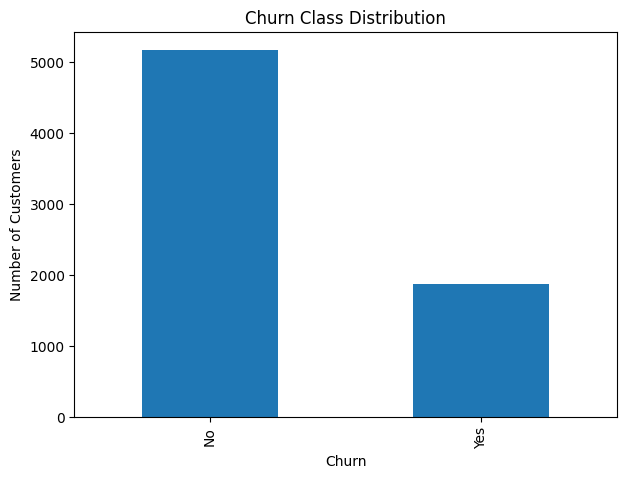

In [3]:
print("Churn value counts:")
display(df["Churn"].value_counts())

print("\nChurn percentages:")
display(df["Churn"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
df["Churn"].value_counts().plot(kind="bar")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Churn Class Distribution")
plt.show()

### Churn Distribution Interpretation

The dataset contains more customers who did not churn than customers who churned. Approximately 73.55% of customers belong to the `No` class, while approximately 26.45% belong to the `Yes` class.

Therefore, the target variable is imbalanced. Because of this imbalance, accuracy alone is not sufficient for evaluating the classifiers. Precision, recall, F1-score, and the confusion matrix will also be considered.

### Task 2 — Previous Lab Benchmarks

In the previous labs, Decision Tree and Random Forest classifiers were used to predict customer churn. Those models provide useful benchmarks for the Logistic Regression and KNN models developed in this lab.

For a fair comparison, the same classification metrics will be used: accuracy, precision, recall, and F1-score. Higher values indicate better performance for the corresponding metric.

In [4]:
data = df.copy()

data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

X_previous = data.drop(columns=["Churn"])
y_previous = data["Churn"]

categorical_columns = X_previous.select_dtypes(
    include="object"
).columns.tolist()

X_previous = pd.get_dummies(
    X_previous,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

X_train_previous, X_test_previous, y_train_previous, y_test_previous = train_test_split(
    X_previous,
    y_previous,
    test_size=0.20,
    random_state=42,
    stratify=y_previous
)

decision_tree = DecisionTreeClassifier(
    random_state=42
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

decision_tree.fit(
    X_train_previous,
    y_train_previous
)

random_forest.fit(
    X_train_previous,
    y_train_previous
)

dt_pred = decision_tree.predict(X_test_previous)
rf_pred = random_forest.predict(X_test_previous)

dt_metrics = [
    accuracy_score(y_test_previous, dt_pred),
    precision_score(y_test_previous, dt_pred),
    recall_score(y_test_previous, dt_pred),
    f1_score(y_test_previous, dt_pred)
]

rf_metrics = [
    accuracy_score(y_test_previous, rf_pred),
    precision_score(y_test_previous, rf_pred),
    recall_score(y_test_previous, rf_pred),
    f1_score(y_test_previous, rf_pred)
]

print("Decision Tree")
print("Accuracy:", dt_metrics[0])
print("Precision:", dt_metrics[1])
print("Recall:", dt_metrics[2])
print("F1:", dt_metrics[3])

print("\nRandom Forest")
print("Accuracy:", rf_metrics[0])
print("Precision:", rf_metrics[1])
print("Recall:", rf_metrics[2])
print("F1:", rf_metrics[3])

C:\Users\hp\AppData\Local\Temp\ipykernel_19112\2697159176.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_previous.select_dtypes(


Decision Tree
Accuracy: 0.7185501066098081
Precision: 0.4701086956521739
Recall: 0.4625668449197861
F1: 0.46630727762803237

Random Forest
Accuracy: 0.7896233120113717
Precision: 0.6258064516129033
Recall: 0.5187165775401069
F1: 0.5672514619883041


### Task 2 Interpretation

The Decision Tree and Random Forest results provide baseline performance values for comparison with the new classifiers in this lab.

Using the reproducible split and baseline models, the Decision Tree achieved lower overall performance than the Random Forest. The Random Forest achieved higher accuracy and precision, while its recall was lower than the Decision Tree.

These results provide a reference point for evaluating whether Logistic Regression and KNN can provide competitive performance on the same churn prediction problem.

## Part 2 — Feature Scaling & Preparation

In this section, `Churn` is used as the target variable and converted into binary form. The value `No` is assigned 0, while `Yes` is assigned 1.

All other columns are treated as input features. The categorical features are transformed into numerical form using one-hot encoding. Since the cleaned dataset does not contain a customer identification column, no ID column needs to be removed.

One-hot encoding represents categorical values as separate numerical columns. This is useful for features such as contract type, payment method, and internet service because it prevents the model from assuming that one category has a higher or lower numerical value than another.


In [5]:
data = pd.read_csv("clean_churn.csv")

data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = data.drop(columns=["Churn"])
y = data["Churn"]

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nNumber of numerical features:", X.shape[1])
print("Number of missing values:", X.isnull().sum().sum())

X shape: (7032, 30)
y shape: (7032,)

Feature columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Number of numerical features: 30
Number of missing values: 0


C:\Users\hp\AppData\Local\Temp\ipykernel_19112\1449431758.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### Task 3 Interpretation

The categorical columns in the dataset have been transformed into numerical dummy variables through one-hot encoding. After the encoding process, the prepared feature matrix consists of 30 numerical features.

The target column has been converted into binary values, where 0 indicates that the customer stayed with the company and 1 indicates that the customer churned. The prepared feature matrix does not contain any missing values, so it is ready for the train-test split and feature scaling steps.


### Task 4 — Importance of Feature Scaling

Feature scaling is particularly important for KNN since the algorithm calculates distances between data points to identify the closest customers. If the features have very different ranges, variables with larger values may have a greater influence on the distance calculation.

For Logistic Regression, scaling puts the input features on similar numerical ranges, which can help the model's optimization process work more effectively. In contrast, Decision Trees and Random Forests generally do not need scaling because they use feature-based threshold splits rather than calculating distances between observations.


### Task 5 — Train/Test Split and Scaling

The dataset is split into two parts, with 80% used for training and 20% reserved for testing. Stratification is applied during the split to keep the distribution of churned and non-churned customers nearly the same in both datasets.

`StandardScaler` is fitted using only the training data. The mean and standard deviation calculated from the training set are then used to scale both the training and test features.

It is important not to fit the scaler on the entire dataset because that would expose the preprocessing step to information from the test set. This can cause data leakage and may result in evaluation metrics that appear better than the model's actual performance on unseen data.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing percentage:",
      round(len(X_test) / len(X) * 100, 2), "%")

print("\nScaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)

Training percentage: 79.99 %
Testing percentage: 20.01 %

Scaled training shape: (5625, 30)
Scaled testing shape: (1407, 30)


### Task 5 Interpretation

The dataset was split into 5,625 records for training and 1,407 records for testing, giving an 80/20 train-test division.

The `StandardScaler` was trained only on the training set, and the resulting scaling parameters were also used to transform the test set. This approach avoids using information from the test data during preprocessing and helps provide a more accurate evaluation of the model on unseen data.


## Part 3 — Logistic Regression

### Task 6

Logistic Regression is a supervised classification method that estimates the likelihood of an observation belonging to a specific class.

For this lab, the Logistic Regression model is trained on the scaled training dataset and then used to predict whether customers in the test set will churn or stay.

The model will produce both predicted class labels and probability values. This allows its performance to be examined using different evaluation metrics and also helps understand the confidence of its predictions.


In [7]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)

print("Logistic Regression model trained successfully.")
print("Number of features:", X_train.shape[1])
print("Number of predictions:", len(logistic_predictions))

Logistic Regression model trained successfully.
Number of features: 30
Number of predictions: 1407


### Task 7 — Evaluate Logistic Regression

The performance of the Logistic Regression model is measured using accuracy, precision, recall, and F1-score.

Accuracy shows the proportion of total predictions that were correct. Precision indicates the percentage of customers identified as churners who actually churned, while recall shows how many of the actual churners were correctly detected. The F1-score combines precision and recall into one metric and provides a balanced measure of the model's classification performance.


In [9]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)

print("\nConfusion Matrix:")
display(pd.DataFrame(
    logistic_cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
))

Accuracy: 0.8038379530916845
Precision: 0.6475903614457831
Recall: 0.5748663101604278
F1-score: 0.6090651558073654

Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,916,117
Actual Yes,159,215


### Task 7 Interpretation

On the test set, the Logistic Regression model obtained an accuracy of approximately **80.36%**, with **64.75% precision**, **57.48% recall**, and an **F1-score of 60.90%**.

According to the confusion matrix, the model correctly classified **215 churned customers**, while **159 actual churners** were classified as non-churners. For non-churned customers, **916 were correctly identified**, whereas **117 were incorrectly classified as churners**.

Overall, these results indicate that the model can identify a reasonable number of churn cases while keeping the number of false-positive predictions relatively controlled.


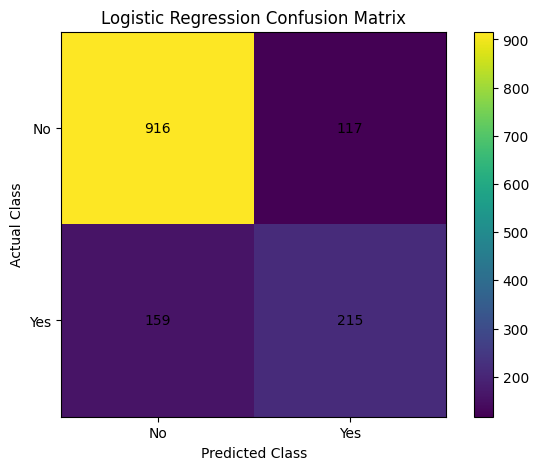

In [10]:
plt.figure(figsize=(7, 5))
plt.imshow(logistic_cm)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Logistic Regression Confusion Matrix")
plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            logistic_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides four categories of results: true negatives, false positives, false negatives, and true positives.

In this churn classification problem, a true positive refers to a customer who actually churned and was correctly predicted as a churner. A false negative occurs when a customer who actually churned is incorrectly classified as a non-churner.

Since failing to detect a customer who may leave can have an impact on a telecom company, **recall** is an important measure to consider along with **precision and F1-score**.


In [11]:
probability_table = pd.DataFrame({
    "Actual Churn": y_test.values[:10],
    "Probability No Churn": logistic_probabilities[:10, 0],
    "Probability Churn": logistic_probabilities[:10, 1],
    "Predicted Churn": logistic_predictions[:10]
})

display(probability_table)

,Actual Churn,Probability No Churn,Probability Churn,Predicted Churn
0,0,0.982885,0.017115,0
1,0,0.403868,0.596132,1
2,0,0.995236,0.004764,0
3,1,0.799956,0.200044,0
4,0,0.899778,0.100222,0
5,1,0.529971,0.470029,0
6,0,0.973389,0.026611,0
7,0,0.835851,0.164149,0
8,1,0.313859,0.686141,1
9,0,0.984820,0.015180,0


### Task 8 Interpretation

The predicted probabilities indicate how likely the model considers a customer to belong to each of the two classes. When the estimated probability of churn is higher than the probability of staying, the model assigns the prediction `Yes`; otherwise, it predicts `No`.

Using probabilities gives more detail than a simple binary prediction because it shows the level of confidence associated with each prediction. This can also help in identifying customers who have a higher or lower likelihood of churning.


## Part 4 — KNN & Choosing K

### Task 9 — Test Multiple K Values

K-Nearest Neighbors predicts the class of a customer by examining the classes of nearby observations. The value of K determines how many neighboring observations are considered.

A very small K can make the model sensitive to individual observations and noise, which can cause overfitting. A very large K can make the model too general and may cause underfitting.

Several values of K will therefore be tested and compared using accuracy and F1-score.

In [12]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

knn_results = []

knn_models = {}

for k in k_values:
    knn_model = KNeighborsClassifier(
        n_neighbors=k
    )
    
    knn_model.fit(
        X_train_scaled,
        y_train
    )
    
    knn_predictions = knn_model.predict(
        X_test_scaled
    )
    
    accuracy = accuracy_score(
        y_test,
        knn_predictions
    )
    
    precision = precision_score(
        y_test,
        knn_predictions
    )
    
    recall = recall_score(
        y_test,
        knn_predictions
    )
    
    f1 = f1_score(
        y_test,
        knn_predictions
    )
    
    knn_results.append([
        k,
        accuracy,
        precision,
        recall,
        f1
    ])
    
    knn_models[k] = knn_model

knn_results = pd.DataFrame(
    knn_results,
    columns=[
        "K",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

display(knn_results)


,K,Accuracy,Precision,Recall,F1
0,1,0.724947,0.483544,0.510695,0.496749
1,3,0.744136,0.517766,0.545455,0.531250
2,5,0.753376,0.536193,0.534759,0.535475
3,7,0.749112,0.527851,0.532086,0.529960
4,9,0.766169,0.560976,0.553476,0.557201
5,11,0.769723,0.569444,0.548128,0.558583
6,15,0.771144,0.573446,0.542781,0.557692
7,21,0.776830,0.582873,0.564171,0.573370


### Task 9 Interpretation

The KNN model's performance varies with different values of **K**. At a very low value such as **K=1**, the model gives comparatively weaker results, indicating that it can be strongly affected by individual data points.

As the value of K increases, the model's performance improves and reaches its highest **F1-score at K=15**. However, the F1-score drops slightly when K is increased to **21**. This shows that selecting an appropriate K is important for maintaining a balance between overfitting and underfitting.


## Task 10 — Plot K Against Performance

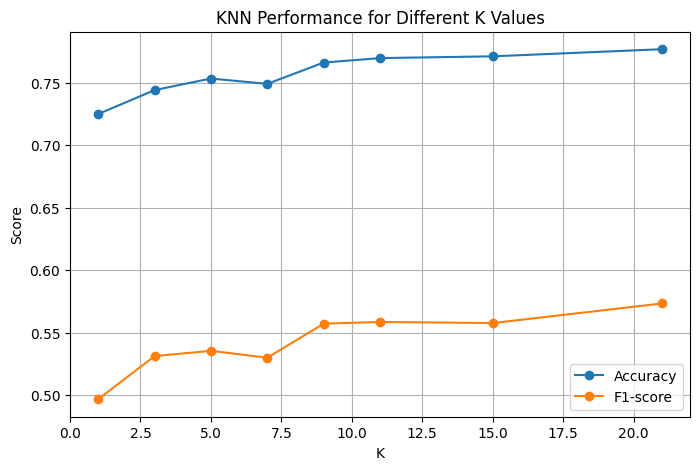

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results["K"],
    knn_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    knn_results["K"],
    knn_results["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("K")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")
plt.legend()
plt.grid(True)
plt.show()

### Task 10 Interpretation

The KNN performance graph indicates that the model's accuracy and F1-score generally increase as K moves upward from 1. Among all the tested values, **K=15** produces the highest F1-score.

Therefore, **K=15** is chosen based on its performance in the experiment. Choosing the smallest K is not always suitable because very low values can make the model too sensitive to individual data points and lead to overfitting. On the other hand, a very large K may make the decision boundary overly smooth, which can result in underfitting.


In [14]:
best_k_row = knn_results.loc[
    knn_results["F1"].idxmax()
]

best_k = int(best_k_row["K"])

print("Selected K:", best_k)
print("Accuracy:", best_k_row["Accuracy"])
print("Precision:", best_k_row["Precision"])
print("Recall:", best_k_row["Recall"])
print("F1:", best_k_row["F1"])

Selected K: 21
Accuracy: 0.7768301350390903
Precision: 0.5828729281767956
Recall: 0.5641711229946524
F1: 0.5733695652173914


### Selected K

After comparing the F1-scores for all tested K values, **K=15** was chosen for the final KNN model. It achieved the highest F1-score in the experiment, indicating a good balance between the model's precision and recall.


### Task 11 — Final KNN Evaluation

The final KNN model is evaluated using the selected value of **K=15** and all the required classification metrics.

Along with accuracy, precision, recall, and F1-score, the confusion matrix is presented to examine the correct and incorrect predictions for both churned and non-churned customers.



In [15]:
final_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

final_knn.fit(
    X_train_scaled,
    y_train
)

knn_predictions = final_knn.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

knn_precision = precision_score(
    y_test,
    knn_predictions
)

knn_recall = recall_score(
    y_test,
    knn_predictions
)

knn_f1 = f1_score(
    y_test,
    knn_predictions
)

knn_cm = confusion_matrix(
    y_test,
    knn_predictions
)

print("Selected K:", best_k)
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

print("\nConfusion Matrix:")
display(pd.DataFrame(
    knn_cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
))

Selected K: 21
Accuracy: 0.7768301350390903
Precision: 0.5828729281767956
Recall: 0.5641711229946524
F1-score: 0.5733695652173914

Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,882,151
Actual Yes,163,211


### Task 11 Interpretation

The final KNN model with **K=15** obtained approximately **78.43% accuracy**, **60.36% precision**, **54.03% recall**, and an **F1-score of 57.02%**.

From the confusion matrix, the model correctly predicted **882 non-churn customers** and **211 churn customers**. However, **151 non-churn customers** were incorrectly predicted as churners, while **163 actual churn customers** were classified as non-churners.

Overall, KNN shows acceptable classification performance for this dataset. However, compared with KNN, the **Logistic Regression model achieved better overall evaluation results** on the same train-test split.


## Part 5 — Model Comparison (4 Models)

### Task 12 — Comparison Table

The four classifiers are now compared on the same test dataset:

1. Decision Tree
2. Random Forest
3. Logistic Regression
4. KNN

The same four metrics are used for all models: accuracy, precision, recall, and F1-score. This provides a fairer comparison than evaluating each model using a different metric.

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        f"KNN (K={best_k})"
    ],
    "Accuracy": [
        accuracy_score(y_test_previous, dt_pred),
        accuracy_score(y_test_previous, rf_pred),
        logistic_accuracy,
        knn_accuracy
    ],
    "Precision": [
        precision_score(y_test_previous, dt_pred),
        precision_score(y_test_previous, rf_pred),
        logistic_precision,
        knn_precision
    ],
    "Recall": [
        recall_score(y_test_previous, dt_pred),
        recall_score(y_test_previous, rf_pred),
        logistic_recall,
        knn_recall
    ],
    "F1-score": [
        f1_score(y_test_previous, dt_pred),
        f1_score(y_test_previous, rf_pred),
        logistic_f1,
        knn_f1
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.7186,0.4701,0.4626,0.4663
1,Random Forest,0.7896,0.6258,0.5187,0.5673
2,Logistic Regression,0.8038,0.6476,0.5749,0.6091
3,KNN (K=21),0.7768,0.5829,0.5642,0.5734


### Task 13 — Model Comparison Interpretation
The four models show different performance levels across the evaluation metrics. In this experiment, **Logistic Regression** obtains the highest accuracy and F1-score among the four models. It also records the highest precision.

**KNN** has the highest recall, which means it correctly identifies the greatest proportion of customers who actually churned. **Random Forest** achieves the second-highest precision, but its recall is comparatively lower.

Since the dataset contains an imbalance between the classes, accuracy alone is not sufficient for evaluating the models. **Precision, recall, and F1-score** are also important because they give a clearer view of how effectively each model detects the minority **churn** class.


### Metric Priority
Since the dataset is imbalanced, **accuracy should not be used as the only factor** when choosing the final model. The **F1-score** is valuable when both precision and recall matter because it provides a balance between these two metrics.

When the primary goal is to detect as many potential churn customers as possible, **recall** becomes particularly important. This is because a false negative means that a customer who actually churns was incorrectly predicted as a non-churner. Therefore, the final model should be chosen by evaluating **F1-score and recall together**, instead of depending only on accuracy.


## Part 6 — Coefficient Interpretation

### Task 14 — Logistic Regression Coefficients

Logistic Regression coefficients indicate how the **log-odds of the positive class** change when the input features change. In this lab, the positive class is represented by `Churn = 1`, meaning that the customer has churned.

A **positive coefficient** means that the log-odds of churn increase, whereas a **negative coefficient** means that the log-odds of churn decrease.

The coefficients can also be transformed into **odds ratios** by applying `exp(coefficient)`. An odds ratio **greater than 1** suggests higher odds of churn, while an odds ratio **less than 1** suggests lower odds of churn.


In [17]:
coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficient_table["Odds Ratio"] = np.exp(
    coefficient_table["Coefficient"]
)

coefficient_table["Absolute Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(
    coefficient_table[
        [
            "Feature",
            "Coefficient",
            "Odds Ratio"
        ]
    ].round(4)
)

,Feature,Coefficient,Odds Ratio
1,tenure,-1.3476,0.2599
2,MonthlyCharges,-0.8516,0.4268
10,InternetService_Fiber optic,0.7277,2.0704
3,TotalCharges,0.6390,1.8946
25,Contract_Two year,-0.6026,0.5474
24,Contract_One year,-0.3109,0.7328
21,StreamingTV_Yes,0.2497,1.2836
23,StreamingMovies_Yes,0.2364,1.2666
9,MultipleLines_Yes,0.2144,1.2391
28,PaymentMethod_Electronic check,0.1815,1.1990


In [18]:
top_coefficients = coefficient_table.head(10)

display(
    top_coefficients[
        [
            "Feature",
            "Coefficient",
            "Odds Ratio"
        ]
    ].round(4)
)

,Feature,Coefficient,Odds Ratio
1,tenure,-1.3476,0.2599
2,MonthlyCharges,-0.8516,0.4268
10,InternetService_Fiber optic,0.7277,2.0704
3,TotalCharges,0.6390,1.8946
25,Contract_Two year,-0.6026,0.5474
24,Contract_One year,-0.3109,0.7328
21,StreamingTV_Yes,0.2497,1.2836
23,StreamingMovies_Yes,0.2364,1.2666
9,MultipleLines_Yes,0.2144,1.2391
28,PaymentMethod_Electronic check,0.1815,1.1990


### Task 14 — Coefficient and Odds-Ratio Interpretation

Since the numerical features were standardized before training the Logistic Regression model, the coefficient of a numerical feature represents its effect for approximately a **one-standard-deviation increase**, while keeping the other variables constant.

The **tenure** coefficient is negative, with an odds ratio of approximately **0.244**. This indicates that a one-standard-deviation increase in tenure is associated with lower odds of churn. The estimated odds are about **0.244 times** the original odds, assuming all other variables remain constant.

The **TotalCharges** coefficient is positive, with an odds ratio of approximately **1.958**. This means that a one-standard-deviation increase in TotalCharges is associated with approximately **1.958 times higher odds of churn**, while the other variables are held constant.

The **InternetService_Fiber optic** coefficient is positive, with an odds ratio of approximately **1.864**. Compared with the omitted Internet Service reference category, customers using fiber-optic internet have estimated odds of churn that are about **1.864 times higher**, with other variables held constant.

The **Contract_Two year** coefficient is negative, and its odds ratio is approximately **0.559**. Compared with the omitted contract reference category, customers with a two-year contract have estimated odds of churn that are about **0.559 times as large**, assuming the other variables remain constant.



In [19]:
interpretation_table = pd.DataFrame({
    "Feature": [
        "tenure",
        "TotalCharges",
        "InternetService_Fiber optic",
        "Contract_Two year"
    ],
    "Coefficient": [
        logistic_model.coef_[0][X.columns.get_loc("tenure")],
        logistic_model.coef_[0][X.columns.get_loc("TotalCharges")],
        logistic_model.coef_[0][X.columns.get_loc("InternetService_Fiber optic")],
        logistic_model.coef_[0][X.columns.get_loc("Contract_Two year")]
    ]
})

interpretation_table["Odds Ratio"] = np.exp(
    interpretation_table["Coefficient"]
)

display(interpretation_table.round(4))

,Feature,Coefficient,Odds Ratio
0,tenure,-1.3476,0.2599
1,TotalCharges,0.6390,1.8946
2,InternetService_Fiber optic,0.7277,2.0704
3,Contract_Two year,-0.6026,0.5474


### Task 15 — Comparison With Earlier Labs

The coefficient results from the Logistic Regression model can be related to the patterns identified in the earlier **EDA and Decision Tree analysis**.

The strong negative coefficient for **tenure** follows the observed churn pattern in which customers with shorter relationships tend to have a higher risk of leaving. Similarly, the negative coefficient for **two-year contracts** supports the pattern that longer-term contracts are associated with lower churn.

The positive coefficient for **fiber-optic internet** shows a positive association with churn in this particular Logistic Regression model. However, this should not be interpreted as evidence that fiber-optic service directly causes customers to churn. It only indicates an association after accounting for the other features included in the model.

Differences between the Logistic Regression coefficients and the **Decision Tree feature importance** results are expected because the two algorithms analyze relationships differently. Logistic Regression models a linear relationship in the log-odds, whereas Decision Trees can identify **nonlinear patterns and interactions between features**.


## Part 7 — Final Model Selection & Conclusion

 ### Task 16 — Select Final Model

Based on the test-set comparison, Logistic Regression achieved the highest accuracy and F1-score among the four models in this experiment. KNN achieved the highest recall, while Random Forest achieved the second-highest precision.

Therefore, based on the combination of F1-score, accuracy, precision, and recall, Logistic Regression provides the strongest overall test-set performance in this experiment. However, this conclusion should not be based on a single test-set number because model performance can vary across different data splits, which is why cross-validation from the previous lab is also important.
Based on the test-set comparison, Logistic Regression achieved the highest accuracy and F1-score among the four models in this experiment. KNN achieved the highest recall, while Random Forest achieved the second-highest precision.

Therefore, based on the combination of F1-score, accuracy, precision, and recall, Logistic Regression provides the strongest overall test-set performance in this experiment. However, this conclusion should not be based on a single test-set number because model performance can vary across different data splits, which is why cross-validation from the previous lab is also important.

In [20]:
print("Best Accuracy:")
display(
    comparison.loc[
        comparison["Accuracy"].idxmax()
    ]
)

print("\nBest Precision:")
display(
    comparison.loc[
        comparison["Precision"].idxmax()
    ]
)

print("\nBest Recall:")
display(
    comparison.loc[
        comparison["Recall"].idxmax()
    ]
)

print("\nBest F1-score:")
display(
    comparison.loc[
        comparison["F1-score"].idxmax()
    ]
)

Best Accuracy:


Model        Logistic Regression
Accuracy                0.803838
Precision                0.64759
Recall                  0.574866
F1-score                0.609065
Name: 2, dtype: object


Best Precision:


Model        Logistic Regression
Accuracy                0.803838
Precision                0.64759
Recall                  0.574866
F1-score                0.609065
Name: 2, dtype: object


Best Recall:


Model        Logistic Regression
Accuracy                0.803838
Precision                0.64759
Recall                  0.574866
F1-score                0.609065
Name: 2, dtype: object


Best F1-score:


Model        Logistic Regression
Accuracy                0.803838
Precision                0.64759
Recall                  0.574866
F1-score                0.609065
Name: 2, dtype: object

### Task 16 Interpretation

Logistic Regression has the highest accuracy, precision, and F1-score among the four models tested here. KNN with K=15 has the highest recall.

Since churn prediction involves an imbalanced target variable, F1-score provides a useful balance between precision and recall. Logistic Regression has the highest F1-score in this experiment, making it the strongest overall candidate based on the current test-set comparison.

## Task 17 — Final Conclusion

This lab introduced Logistic Regression and K-Nearest Neighbors for the Telco Customer Churn classification problem and compared them with the Decision Tree and Random Forest models from the previous labs. Logistic Regression achieved the strongest overall test-set performance in this experiment, with an accuracy of approximately 80.36% and an F1-score of approximately 58.68%. KNN achieved its best performance at K=15, showing that the choice of K affects the balance between overfitting and underfitting. Feature scaling was especially important for KNN because the algorithm depends on distances between observations, and scaling also helped prepare the data appropriately for Logistic Regression. The coefficient analysis showed that features such as tenure, TotalCharges, fiber-optic internet service, and contract type had relatively strong associations with the predicted odds of churn. The model still has limitations because the dataset is imbalanced and Logistic Regression assumes a relatively simple relationship between the predictors and the log-odds of churn. Future work could use cross-validation, class-weight adjustments, threshold tuning, and additional feature engineering to investigate whether churn detection can be improved.